In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
image_file = os.path.abspath("image.jpg")
template_file = os.path.abspath("template.jpg")

In [3]:
image = cv2.imread(image_file)
img_g = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [24]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img_g)

In [25]:
tempRaw = cv2.imread(template_file, 0)
tempEnhanced = clahe.apply(tempRaw)
_, tempBin = cv2.threshold(tempEnhanced, 120, 255, cv2.THRESH_BINARY_INV)
coords = cv2.findNonZero(tempBin)
tx, ty, tw, th = cv2.boundingRect(coords)
tCrop = tempEnhanced[ty:ty+th, tx:tx+tw]

In [26]:
orig_template_width = tw
orig_template_height = th
print(f"原始模板尺寸: 宽度={orig_template_width}, 高度={orig_template_height}")
print(f"原始模板裁剪区域: 左上角({tx}, {ty}), 尺寸{tw}x{th}")

原始模板尺寸: 宽度=212, 高度=73
原始模板裁剪区域: 左上角(11, 3), 尺寸212x73


In [27]:
all_matches = []
Scales = [0.9, 1.0, 1.1]
Angles = range(0, 360, 10)
threshold = 0.75

In [29]:
for Scale in Scales:
    Sw = int(orig_template_width * Scale)
    Sh = int(orig_template_height * Scale)
    r_size = cv2.resize(tCrop, (Sw, Sh))

    for angle in Angles:
        h, w = r_size.shape[:2]
        center = (w // 2, h // 2)

        angle_rad = np.deg2rad(angle)
        cos_a = abs(np.cos(angle_rad))
        sin_a = abs(np.sin(angle_rad))

        rotated_w = int(w * cos_a + h * sin_a)
        rotated_h = int(w * sin_a + h * cos_a)

        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        M[0, 2] += (rotated_w - w) / 2
        M[1, 2] += (rotated_h - h) / 2

        rotated_template = cv2.warpAffine(r_size, M, (rotated_w, rotated_h), borderValue=255)

        result = cv2.matchTemplate(img_clahe, rotated_template, cv2.TM_CCOEFF_NORMED)
        locations = np.where(result >= threshold)

        for pt in zip(*locations[::-1]):
            score = result[pt[1], pt[0]]
            all_matches.append({
                'top_left': (pt[0], pt[1]),
                'center': (pt[0] + rotated_w // 2, pt[1] + rotated_h // 2),
                'angle': angle,
                'scale': Scale,
                'rotated_size': (rotated_w, rotated_h),
                'original_size': (w, h),
                'score': score
            })

print(f"匹配框数: {len(all_matches)}")

before_nms_img = image.copy()

for match in all_matches:
    x, y = match['top_left']
    angle = match['angle']
    scale = match['scale']
    center_x, center_y = match['center']
    rotated_w, rotated_h = match['rotated_size']
    original_w, original_h = match['original_size']

    corners = np.array([
        [-original_w/2, -original_h/2],
        [original_w/2, -original_h/2],
        [original_w/2, original_h/2],
        [-original_w/2, original_h/2]
    ])

    angle_rad = np.deg2rad(-angle)
    cos_theta = np.cos(angle_rad)
    sin_theta = np.sin(angle_rad)

    rotation_matrix = np.array([
        [cos_theta, -sin_theta],
        [sin_theta, cos_theta]
    ])

    rotated_corners = np.dot(corners, rotation_matrix.T)

    rotated_corners[:, 0] += center_x
    rotated_corners[:, 1] += center_y

    pts = rotated_corners.astype(np.int32)
    cv2.polylines(before_nms_img, [pts], True, (0, 0, 255), 1)


匹配框数: 5282


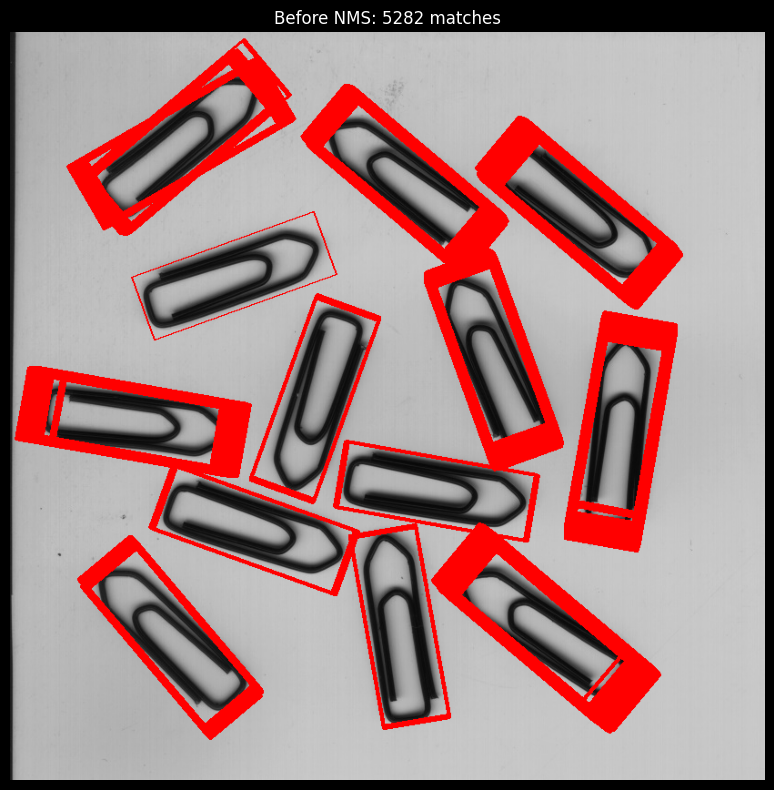

In [30]:
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(before_nms_img, cv2.COLOR_BGR2RGB))
plt.title(f'Before NMS: {len(all_matches)} matches')
plt.axis('off')
plt.tight_layout()
plt.show()

经过NMS后的框数: 13


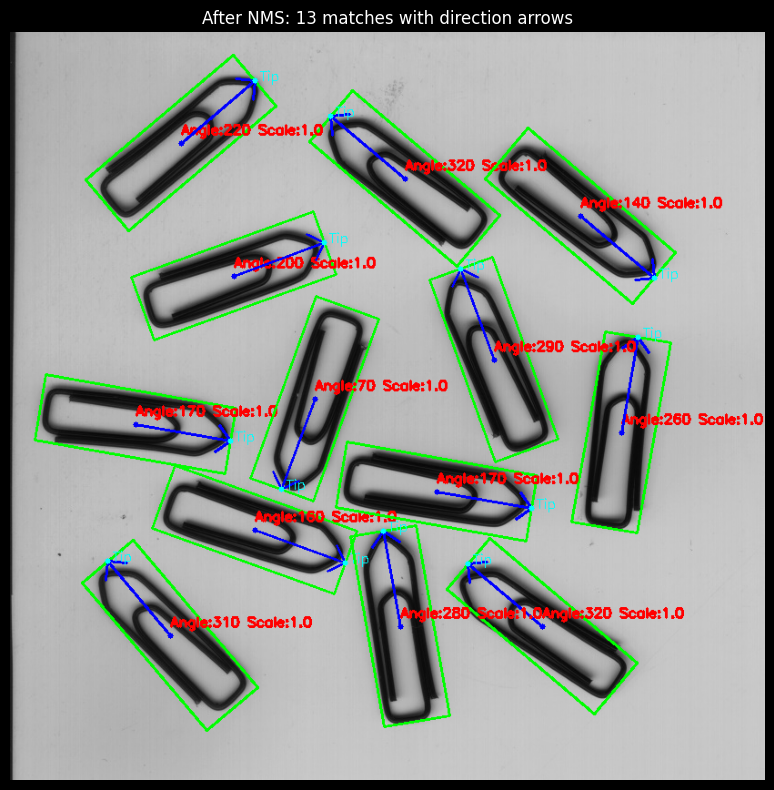

In [53]:
result_img = image.copy()
final_matches = []

if len(all_matches) > 0:
    boxes = []
    scores = []

    for match in all_matches:
        x, y = match['top_left']
        rotated_w, rotated_h = match['rotated_size']
        boxes.append([x, y, x + rotated_w, y + rotated_h])
        scores.append(match['score'])

    boxes = np.array(boxes)
    scores = np.array(scores)

    idxs = np.argsort(scores)[::-1]
    keep = []

    while len(idxs) > 0:
        i = idxs[0]
        keep.append(i)

        if len(idxs) == 1:
            break

        xx1 = np.maximum(boxes[i, 0], boxes[idxs[1:], 0])
        yy1 = np.maximum(boxes[i, 1], boxes[idxs[1:], 1])
        xx2 = np.minimum(boxes[i, 2], boxes[idxs[1:], 2])
        yy2 = np.minimum(boxes[i, 3], boxes[idxs[1:], 3])

        w = np.maximum(0.0, xx2 - xx1 + 1)
        h = np.maximum(0.0, yy2 - yy1 + 1)

        inter = w * h
        area_i = (boxes[i, 2] - boxes[i, 0] + 1) * (boxes[i, 3] - boxes[i, 1] + 1)
        area_j = (boxes[idxs[1:], 2] - boxes[idxs[1:], 0] + 1) * (boxes[idxs[1:], 3] - boxes[idxs[1:], 1] + 1)
        iou = inter / (area_i + area_j - inter)

        inds = np.where(iou <= 0.3)[0]
        idxs = idxs[inds + 1]

    final_matches = [all_matches[i] for i in keep]
    final_boxes_count = len(final_matches)
    print(f"经过NMS后的框数: {final_boxes_count}")

    for match in final_matches:
        x, y = match['top_left']
        angle = match['angle']
        scale = match['scale']
        center_x, center_y = match['center']
        rotated_w, rotated_h = match['rotated_size']
        original_w, original_h = match['original_size']

        corners = np.array([
            [-original_w/2, -original_h/2],
            [original_w/2, -original_h/2],
            [original_w/2, original_h/2],
            [-original_w/2, original_h/2]
        ])

        angle_rad = np.deg2rad(-angle)
        cos_theta = np.cos(angle_rad)
        sin_theta = np.sin(angle_rad)

        rotation_matrix = np.array([
            [cos_theta, -sin_theta],
            [sin_theta, cos_theta]
        ])

        rotated_corners = np.dot(corners, rotation_matrix.T)
        rotated_corners[:, 0] += center_x
        rotated_corners[:, 1] += center_y

        pts = rotated_corners.astype(np.int32)
        cv2.polylines(result_img, [pts], True, (0, 255, 0), 2)

        cv2.circle(result_img, (int(center_x), int(center_y)), 3, (255, 0, 0), -1)

        cv2.putText(result_img, f"Angle:{angle} Scale:{scale:.1f}",
                   (int(center_x), int(center_y-10)),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        top_edge_center = (rotated_corners[0] + rotated_corners[1]) / 2
        bottom_edge_center = (rotated_corners[2] + rotated_corners[3]) / 2

        if original_h > original_w:
            top_center = bottom_edge_center
            bottom_center = bottom_edge_center

            tip_point = top_center

            arrow_start = (int(center_x), int(center_y))
            arrow_end = (int(tip_point[0]), int(tip_point[1]))

        else:
            left_edge_center = (rotated_corners[0] + rotated_corners[3]) / 2
            right_edge_center = (rotated_corners[1] + rotated_corners[2]) / 2

            tip_point = left_edge_center

            arrow_start = (int(center_x), int(center_y))
            arrow_end = (int(tip_point[0]), int(tip_point[1]))


        cv2.arrowedLine(result_img, arrow_start, arrow_end, (255, 0, 0), 2, tipLength=0.2)

        cv2.circle(result_img, arrow_end, 3, (255, 255, 0), -1)

        cv2.putText(result_img, f"Tip",
                   (int(tip_point[0]) + 5, int(tip_point[1])),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

else:
    print("没有找到匹配！")

# 显示结果
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title(f'After NMS: {final_boxes_count} matches with direction arrows')
plt.axis('off')
plt.tight_layout()
plt.show()